# The gamme function

A commonly occuring function in physics calculations is the gamma function $\Gamma(a)$, which is defined by the integral

$$\Gamma(a) = \int_{0}^{∞}x^{a-1}e^{-x}dx$$

There is no closed-form expression for the gamma function, but one can calculate its value for given $a$ by performing the integral above numerically. This project is all about evaluating this integral and how to do it properly.


But first, let's have a look at what the integrand $x^{a-1}e^{-x}$ looks like for a few values of $a$!

In [891]:
import matplotlib.pyplot as plt
import numpy as np

In [892]:
def f(a, x):
    return x**(a-1) * np.exp(-x)

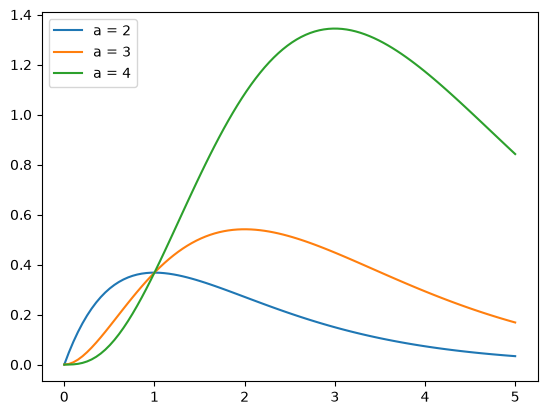

In [893]:
x = np.linspace(0, 5, 100)

y2 = f(2, x)
y3 = f(3, x)
y4 = f(4, x)

plt.plot(x, y2, label="a = 2")
plt.plot(x, y3, label="a = 3")
plt.plot(x, y4, label="a = 4")

plt.legend()
plt.show()

What we can see here is that for each curve our integrand starts at zero, rises to a maximum, and then decays again. A quick analysis also shows that for infinitely large values of x the function will always approach $0$, independently of the value of $a$.

In order to get an accurate value of the gamma function, we need to perform an integral over an infinite range. But numerical techniques don't work for this kind of integrals because we'd need an infinite number of sample points to span an infinite range. Our first mission is to change the integral for one over a finite range which be achieved using a change of variable. For an integral over the range from $0$ to $∞$ a common change of variable is of the forme

$$ z = \frac{x}{c+x}$$

which ultimately gives us

$$x=\frac{zc}{1-z}$$
$$dx=\frac{c}{(1-z)^2}dz$$
$$\int_{0}^{∞}f(x)dx = \int_{0}^{1}\frac{c}{(1-z)^2}f(\frac{zc}{1-z})dz$$

So far so good! But our new integral needs a parameter $c$ and before we take any decision about its value it would be wise to just have a look at our new function for a few values of $c$. Let's plot it when $a$ is, for instance, equal to 2

In [894]:
def integrand_general(a, c, z):
    x = z*c / (1-z)
    first_term = c / (1-z)**2
    return first_term * f(a, x)

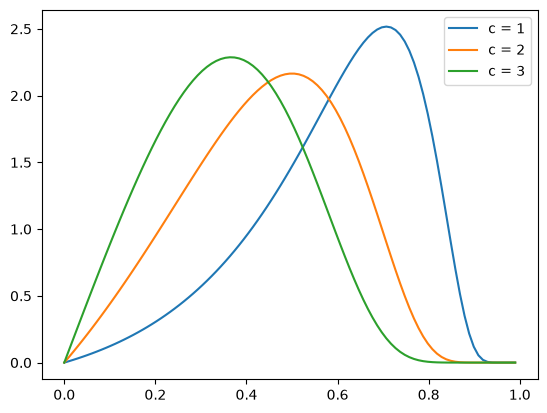

In [895]:
x = np.linspace(0, 1, 100)
x = x[x != 1]

y1 = integrand_general(2, 1, x)
y2 = integrand_general(2, 2, x)
y3 = integrand_general(2, 3, x)

plt.plot(x, y1, label="c = 1")
plt.plot(x, y2, label="c = 2")
plt.plot(x, y3, label="c = 3")

plt.legend()
plt.show()

Here we see that the value of $c$ moves the peak of our function left or right. What we want to avoid is to get a value of c that squash the peak of the curve toward the edge of the interval because it would then be significantly more difficult to integrat. In fact, a value of $c$ when the peak is in the middle would be ideal.

We are now looking for the value of $c$ that gives us the maximum when $z=\frac{1}{2}$. Using a symbolic computation package, one can calculate the derivative of the integrand in its general form and show that 
its root (and thus the peak of the function) is where

$$c=\frac{-1 + 3z - 2z^2 + a - za}{z}$$

and because we want $z=\frac{1}{2}$ we simply get $c=a$, giving us our ideal integrand. With $f=x^{a-1}e^{-x}$ we now have

$$\int_{0}^{∞}f(x)dx = \int_{0}^{1}\frac{a}{(1-z)^2}f(\frac{za}{1-z})dz$$

Let's check it out by plotting our centered integrand for a few values of $a$

In [896]:
def integrand_centered(a, z):
    return integrand_general(a, a, z)

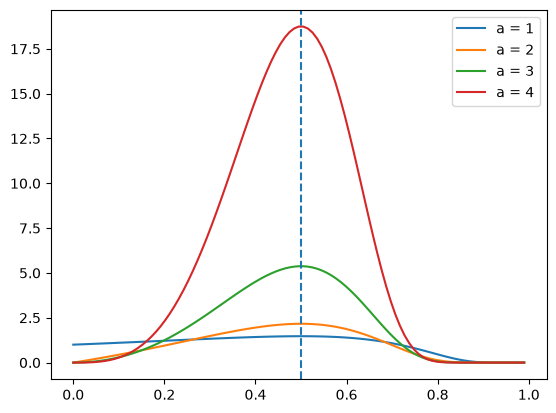

In [897]:
x = np.linspace(0, 1, 100)
x = x[x != 1]

y1 = integrand_centered(1, x)
y2 = integrand_centered(2, x)
y3 = integrand_centered(3, x)
y4 = integrand_centered(4, x)

plt.plot(x, y1, label="a = 1")
plt.plot(x, y2, label="a = 2")
plt.plot(x, y3, label="a = 3")
plt.plot(x, y4, label="a = 4")

plt.axvline(x=0.5, linestyle='--')

plt.legend()
plt.show()

Now that our integrand is behaving well, we can perform the integration and see how our results compare to other packages.

In [898]:
import scipy as sc

def gamma(a):
    return sc.integrate.quad(lambda x: integrand_centered(a, x), 0, 1)[0]

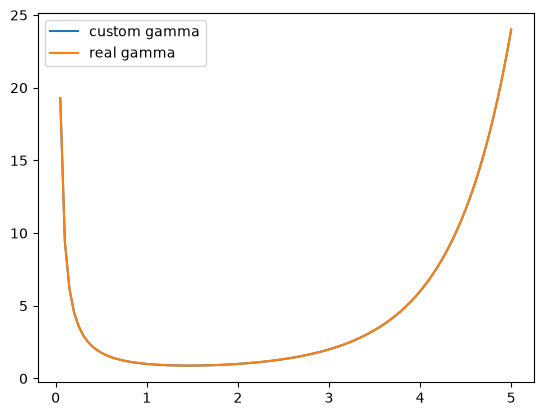

In [899]:
x = np.linspace(0, 5, 100)
x = x[x != 0]

custom_gamma = list(map(lambda z: gamma(z), x))
real_gamma = sc.special.gamma(x)

plt.plot(x, custom_gamma, label="custom gamma")
plt.plot(x, real_gamma, label="real gamma")

plt.legend()
plt.show()